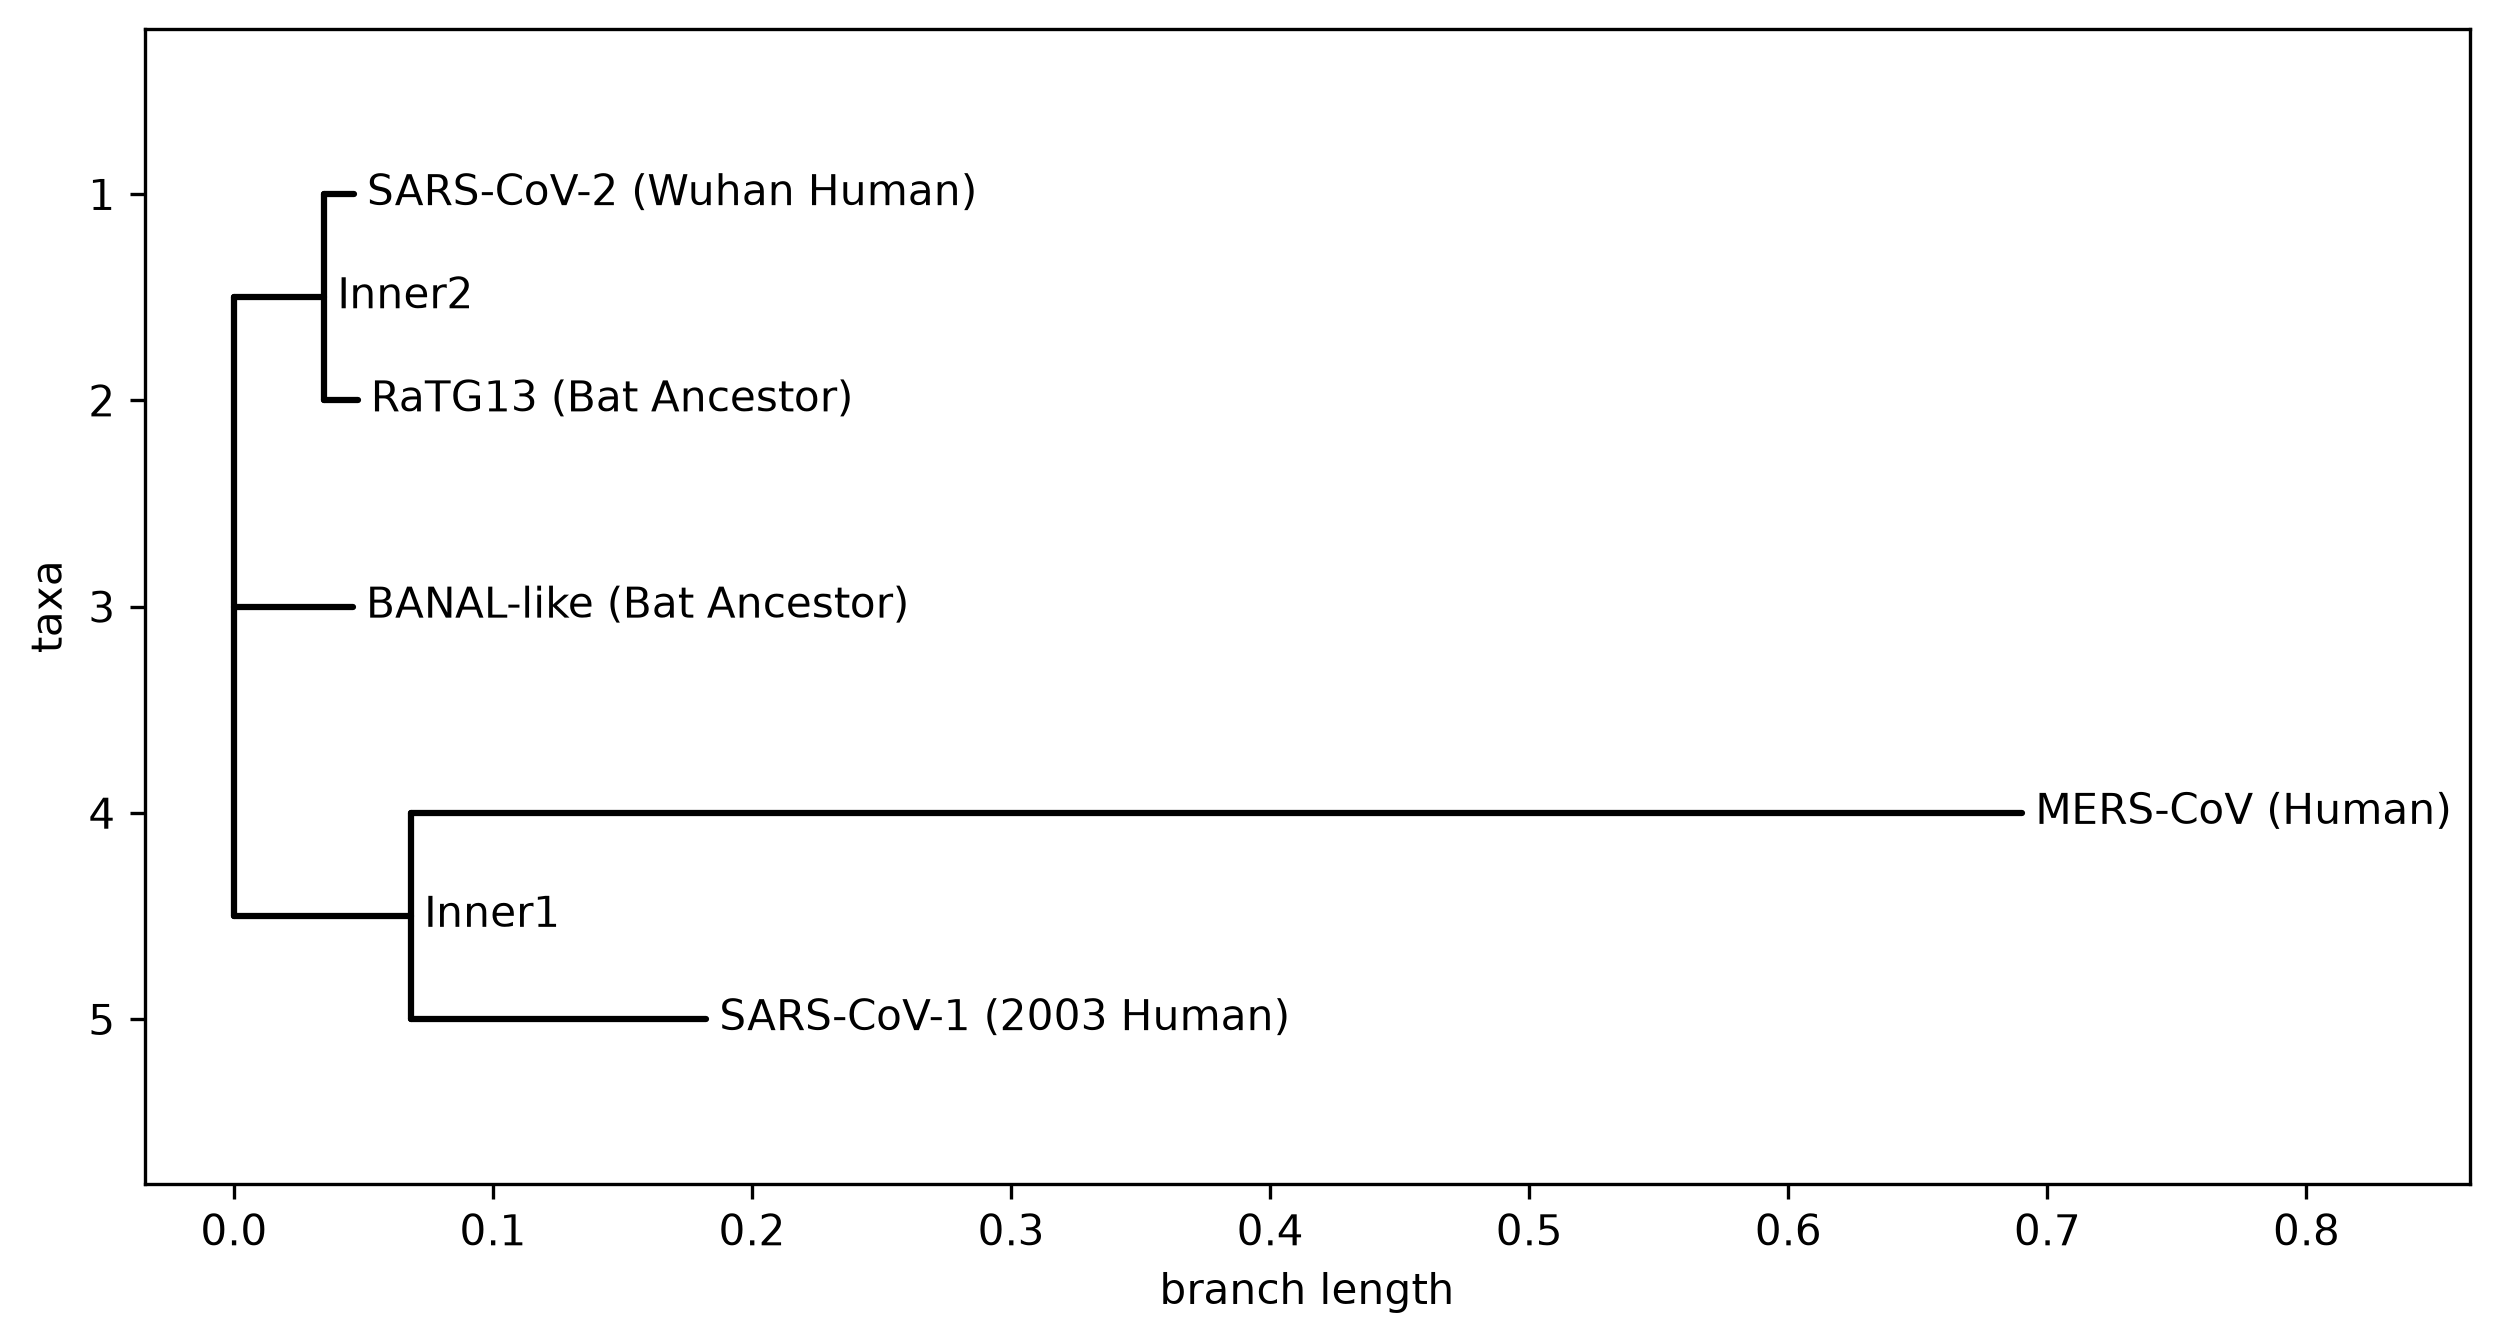

In [4]:
# Import Biopython and important packages
import matplotlib.pyplot as plt
from Bio import AlignIO, Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

# Open alignment file and build the tree
with open("data/clustalw.aln", "r") as aln: 
    alignment = AlignIO.read(aln, "clustal")

calculator = DistanceCalculator('identity')
distance_matrix = calculator.get_distance(alignment)

constructor = DistanceTreeConstructor(calculator)
coronavirus_tree = constructor.build_tree(alignment)
coronavirus_tree.rooted = True

# Labeling of the tree
label_mapping = {
    "YP_009724390.1": "SARS-CoV-2 (Wuhan Human)",
    "AAP13441.1": "SARS-CoV-1 (2003 Human)",
    "YP_009047204.1": "MERS-CoV (Human)",
    "QHR63300.2": "RaTG13 (Bat Ancestor)",
    "XBU76397.1": "BANAL-like (Bat Ancestor)"
}


def clean_labels(node):
    if node.is_terminal(): 
        return label_mapping.get(node.name, node.name) 
    else:
        # Hide 'Inner3' specifically to prevent text overlap!
        if node.name == "Inner3":
            return None
        return node.name 

# Generate the visual output 
fig = plt.figure(figsize=(10, 5), dpi=300)
axes = fig.add_subplot(1, 1, 1)

Phylo.draw(coronavirus_tree, axes=axes, label_func=clean_labels, do_show=False)

# Save tree and show
plt.savefig("coronavirus_p_tree.png", bbox_inches="tight")
plt.show()